# Convolutional Neural Network
Goals : Understanding Behind from 'import pytorch' and 'import tensorflow' how to neural networks works! \
For this project, i using dataset from MNIST (some people say, **MNIST is like 'hello world' to basic Machine Learning**)

In [18]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/hojjatk/mnist-dataset/train-images.idx3-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-labels.idx1-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-images.idx3-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/train-labels.idx1-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-images-idx3-ubyte/t10k-images-idx3-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/train-labels-idx1-ubyte/train-labels-idx1-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/train-images-idx3-ubyte/train-images-idx3-ubyte


In [19]:
!pip install idx2numpy

In [20]:
# Library 
import numpy as np # linear algebra
import idx2numpy 
import matplotlib.pyplot as plt 

# Load Dataset

In [21]:
# for training
x_train_raw = idx2numpy.convert_from_file("/kaggle/input/datasets/hojjatk/mnist-dataset/train-images.idx3-ubyte")
y_train_raw = idx2numpy.convert_from_file("/kaggle/input/datasets/hojjatk/mnist-dataset/train-labels.idx1-ubyte")

# for test
x_test_raw=idx2numpy.convert_from_file("/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-images.idx3-ubyte")
y_test_raw=idx2numpy.convert_from_file("/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-labels.idx1-ubyte")

X_train = x_train_raw.astype('float32') / 255.0 # normalisasi [0,1]
X_test = x_test_raw.astype('float32') / 255.0

# x[:, None, :, :]
# │   │     │   │
# │   │     │   └── W : ambil semua kolom
# │   │     └────── H : ambil semua baris
# │   └──────────── C : SISIPKAN dimensi baru (ukuran 1) di sini
# └──────────────── N : ambil semua gambar

X_train = X_train[:, None, :, :].astype('float32') # N, C (bikin dimensi baru) , H, W
X_test = X_test[:, None, :, :].astype('float32')

y_train = y_train_raw.astype('int64')
y_test = y_test_raw.astype('int64')

print("X train: ", X_train.shape) 
print("y train: ", y_train.shape) 
print("X test: ", X_test.shape) 
print("y test: ", y_test.shape)

X train:  (60000, 1, 28, 28)
y train:  (60000,)
X test:  (10000, 1, 28, 28)
y test:  (10000,)


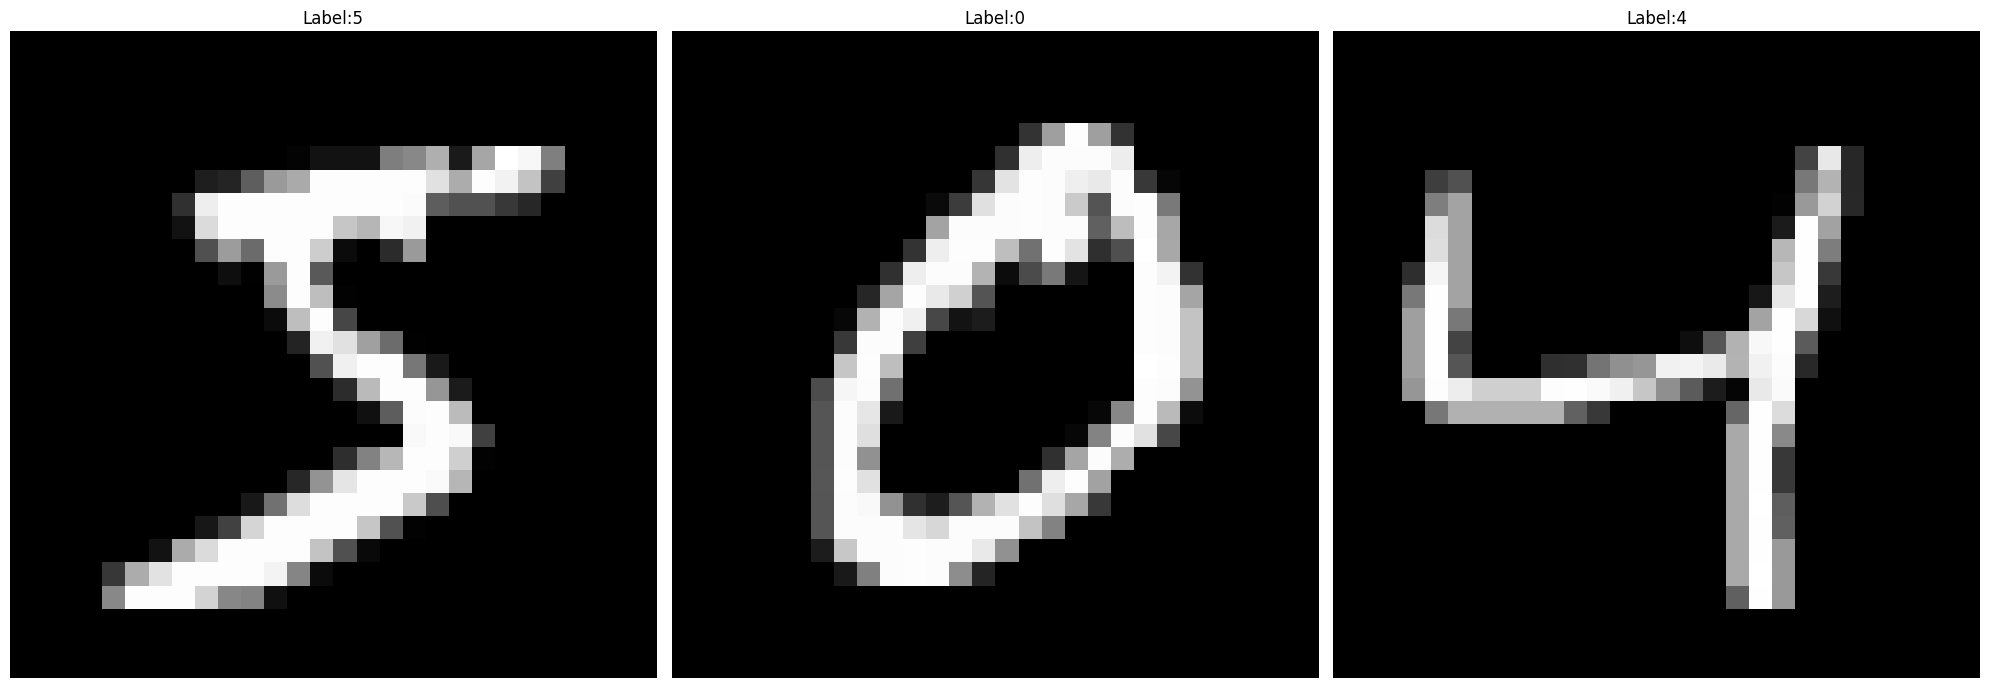

In [22]:
fig,axes=plt.subplots(1,3,figsize=(20,20))
for i,ax in enumerate(axes.flat):
  img=x_train_raw[i] # untuk melihat isi gambar
  ax.imshow(img,cmap="gray")
  ax.axis("off")
  ax.set_title(f"Label:{y_train_raw[i]}")
plt.tight_layout()
plt.show()

# NN ARCHITECTURE

## Init Weight and Parameters

In [23]:
def he_init(shape, n_input):
    """shape = ukuran weight untuk kernel
        n_input = jumlah input yang masuk ke satu neuron/output"""
    weight = np.random.standard_normal(shape)

    weight *= np.sqrt(2.0 / n_input)

    return weight.astype('float32')

def init_parameters_cnn():
    """
    
    Fully Connecteed dengan arsitektur 2 hidden layer
    
    """
    np.random.seed(1234)
    
    # Conv layer
    # Shape kernel yang umum: (jumlah_filter, channel_input, tinggi_kernel, lebar_kernel)
    W1 = he_init(shape=(8,1,3,3), n_input= 3*3*1) # Untuk Kernel
    B1 = np.zeros(8, dtype='float32')

    # Dense layer 1
    # Setelah conv valid 3x3: 28 -> 26
    # Setelah maxpool 2x2: 26 -> 13
    # Flatten: 8 * 13 * 13 = 1352
    W2 = he_init(shape=(1352,128), n_input = 1352)
    B2 = np.zeros(128, dtype='float32') # 128 itu banyak neuron

    # Output layer
    W3 = he_init(shape=(128,10), n_input = 128)
    B3 = np.zeros(10, dtype='float32') # 10 itu banyak neuron

    return W1, B1, W2, B2, W3, B3

## image-to-columns

In [24]:
def im2col(x, kernel_size, stride=1):
    """
    Mengubah setiap patch gambar menjadi satu baris matrix.

    Input:
        x            : (N, C, H, W)
        kernel_size  : (KH, KW)
        stride       : langkah pergeseran kernel

    Output:
        cols         : (N * H_out * W_out, C * KH * KW)
    """

    N, C, H, W = x.shape

    KH, KW = kernel_size

    # Ukuran output convolution
    H_out = (H - KH) // stride + 1 # untuk menentukan ukuran kernel pada height
    W_out = (W - KW) // stride + 1 # untuk menentukan posisi  kernel pada weight

    # Tempat menyimpan semua patch
    cols = np.empty(
        (N, H_out, W_out, C, KH, KW),
        dtype=x.dtype
    )

    # Ambil setiap posisi kernel
    for i in range(KH):
        for j in range(KW):

            cols[:, :, :, :, i, j] = (
                x[
                    :,
                    :,
                    i:i + stride * H_out:stride,
                    j:j + stride * W_out:stride
                ]
                .transpose(0, 2, 3, 1)
            )

    # Ubah semua patch menjadi baris
    cols = cols.reshape(
        N * H_out * W_out,
        C * KH * KW
    )

    return cols

## conv2d_forward

In [25]:
def conv2d_forward(x, W, b, stride=1):

    N, C, H, W_input = x.shape
    F, _, KH, KW = W.shape

    # Padding
    x_pad = x

    # Ambil semua patch
    cols = im2col(
        x_pad,
        kernel_size=(KH, KW),
        stride=stride
    )

    # Ubah kernel menjadi matrix
    W_col = W.reshape(F, -1).T

    # Matrix multiplication
    Z = cols @ W_col + b
    
    pad=0
    
    # Kembalikan ke bentuk feature map
    H_out = (H + 2 * pad - KH) // stride + 1
    W_out = (W_input + 2 *pad - KW) // stride + 1

    Z = Z.reshape(
        N,
        H_out,
        W_out,
        F
    )

    Z = Z.transpose(0, 3, 1, 2) # (N, H_out, W_out, F) transpose(0,3,1,2) ->  (N, F, H_out, W_out)

    conv_cache = (
        x_pad,
        W,
        stride,
        cols,
        x.shape
    )

    return Z, conv_cache

def maxpool_forward(x, size=2, stride=2):
    """
    x : input gambar
    
    Max pooling forward. Nilai yang diambil hanya nilai yang terbesar dari kernel
    """
    n, c, h, width = x.shape

    h_out = (h - size) // stride + 1 # karena channel yang dipakai hanya 1, berarti 1.1 = 1
    w_out = (width - size) // stride + 1

    out = np.empty((n, c, h_out, w_out), dtype=x.dtype)

    for i in range(h_out):
        for j in range(w_out):
            h_start = i * stride
            w_start = j * stride

            window = x[
                :,
                :,
                h_start:h_start + size,
                w_start:w_start + size
            ] # window ini hanya yang dimodif height dan weight + size...

            out[:, :, i, j] = window.max(axis=(2, 3)) # :, : -> 1. Input Image, 2. Input Channel
            
    # Simpan nilai yang dibutuhkan saat backward pass (posisi window
    # dipakai untuk menentukan ke mana gradient harus dialirkan kembali)
    pool_cache = (x, size, stride)

    return out, pool_cache


def flatten_forward(x):
    """
    Ubah feature map 4D menjadi 2D untuk dense layer.
    """
    return x.reshape(x.shape[0], -1), x.shape


In [26]:
def forward_cnn(x, params):
    W1, b1, W2, b2, W3, b3 = params

    # Conv 1
    Z1, cache_conv1 = conv2d_forward(x, W1, b1, stride=1)
    A1 = np.maximum(Z1, 0)  # ReLU

    # Max pooling
    P1, cache_pool1 = maxpool_forward(A1, size=2, stride=2)

    # Flatten
    F, cache_flat = flatten_forward(P1)

    # Dense 1
    Z2 = F @ W2 + b2
    A2 = np.maximum(Z2, 0)  # ReLU

    # Output dense
    Z3 = A2 @ W3 + b3
    
    # layer_caches menyimpan "catatan" dari tiap layer (nilai-nilai forward pass)
    # yang akan dipakai ulang saat menghitung gradient di backward_cnn,
    # supaya kita tidak perlu menghitung ulang dari awal.
    layer_caches = {
        'conv1': cache_conv1,
        'relu1': Z1,
        'pool1': cache_pool1,
        'flat': cache_flat,
        'dense2': (F, W2),
        'relu2': Z2,
        'dense3': (A2, W3),
    }

    return Z3, layer_caches

## conv2d_backward

In [27]:
def conv2d_backward(dz, conv_cache):
    """
    Backward convolution.
    """
    x_pad, w, stride, cols, x_shape = conv_cache
    n, c, h, width = x_shape
    f, _, kh, kw = w.shape

    h_out, w_out = dz.shape[2], dz.shape[3]

    w_col = w.reshape(f, -1).T

    dz_reshaped = dz.transpose(0, 2, 3, 1).reshape(n * h_out * w_out, f)

    # Gradient untuk weight dan bias
    dw_col = cols.T @ dz_reshaped
    dw = dw_col.T.reshape(w.shape)
    db = dz_reshaped.sum(axis=0)

    # Gradient untuk input
    dcols = dz_reshaped @ w_col.T
    dcols = dcols.reshape(n, h_out, w_out, c, kh, kw)

    dx_pad = np.zeros_like(x_pad)

    for i in range(kh):
        for j in range(kw):
            patch = dcols[:, :, :, :, i, j]
            patch = patch.transpose(0, 3, 1, 2)  # (N, C, H_out, W_out)

            dx_pad[
                :,
                :,
                i:i + stride * h_out:stride,
                j:j + stride * w_out:stride
            ] += patch

    dx = dx_pad

    return dx, dw, db


def maxpool_backward(dout, pool_cache):
    """
    Max pooling backward.

    pool_cache: tuple yang disimpan saat forward pass oleh maxpool_forward,
    berisi input asli, ukuran window, dan stride.
    """
    x, size, stride = pool_cache
    n, c, h, width = x.shape

    h_out, w_out = dout.shape[2], dout.shape[3]

    dx = np.zeros_like(x)

    for i in range(h_out):
        for j in range(w_out):
            h_start = i * stride
            w_start = j * stride

            window = x[
                :,
                :,
                h_start:h_start + size,
                w_start:w_start + size
            ]

            window_max = window.max(axis=(2, 3), keepdims=True)
            mask = (window == window_max)

            dx[
                :,
                :,
                h_start:h_start + size,
                w_start:w_start + size
            ] += mask * dout[:, :, i, j][:, :, None, None]

    return dx

def flatten_backward(dout, shape):
    """
    Kembalikan shape dari flatten.
    """
    return dout.reshape(shape)

In [28]:
def backward_cnn(dz3, layer_caches, params):
    """
    layer_caches: dict berisi "catatan" dari tiap layer yang dihasilkan
    forward_cnn (lihat forward_cnn), dipakai di sini untuk menghitung gradient
    tanpa perlu menjalankan ulang forward pass.
    """
    W1, b1, W2, b2, W3, b3 = params

    # Backward dense output
    A2, W3 = layer_caches['dense3']
    dW3 = A2.T @ dz3
    db3 = dz3.sum(axis=0)
    dA2 = dz3 @ W3.T

    # Backward ReLU dense 1
    dz2 = dA2 * (layer_caches['relu2'] > 0)

    # Backward dense 1
    F, W2 = layer_caches['dense2']
    dW2 = F.T @ dz2
    db2 = dz2.sum(axis=0)
    dF = dz2 @ W2.T

    # Backward flatten
    dP1 = flatten_backward(dF, layer_caches['flat'])

    # Backward maxpool
    dA1 = maxpool_backward(dP1, layer_caches['pool1'])

    # Backward ReLU conv
    dz1 = dA1 * (layer_caches['relu1'] > 0)

    # Backward conv
    dX, dW1, db1 = conv2d_backward(dz1, layer_caches['conv1'])

    return dW1, db1, dW2, db2, dW3, db3

## Softmax 

In [29]:
def softmax_cross_entropy(z, y):
    """
    z: logits, shape (N, 10)
    y: label integer, shape (N,)
    """
    z = z - np.max(z, axis=1, keepdims=True)

    exp_z = np.exp(z)
    probs = exp_z / np.sum(exp_z, axis=1, keepdims=True)

    n = z.shape[0]

    loss = -np.log(probs[np.arange(n), y] + 1e-12).mean()

    dz = probs.copy()
    dz[np.arange(n), y] -= 1
    dz /= n

    return loss, dz

## Backpropagation

### OPTIMIZATION
For this scratch, we using gradient descent

In [30]:
def evaluate_cnn(X, y, params, batch_size=512):
    """
    Hitung loss dan accuracy untuk dataset X, y.
    """
    total_loss = 0.0
    correct = 0
    total = 0

    for start in range(0, X.shape[0], batch_size):
        xb = X[start : start + batch_size]
        yb = y[start : start + batch_size]

        logits, _ = forward_cnn(xb, params)
        loss, _ = softmax_cross_entropy(logits, yb)

        bs = yb.shape[0]
        total_loss += loss * bs
        correct += np.sum(np.argmax(logits, axis=1) == yb)
        total += bs

    return total_loss / total, correct / total

In [31]:
def train_cnn_with_history(X, y, X_val, y_val, epochs=1, batch_size=128, lr=0.01):
    params = init_parameters_cnn()
    n = X.shape[0]

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'batch_loss': [],
    }

    for epoch in range(1, epochs + 1):
        idx = np.random.permutation(n)
        X_sh = X[idx]
        y_sh = y[idx]

        losses = []
        correct = 0
        total = 0

        for start in range(0, n, batch_size):
            xb = X_sh[start:start + batch_size]
            yb = y_sh[start:start + batch_size]

            # Forward
            logits, layer_caches = forward_cnn(xb, params)
            loss, dz3 = softmax_cross_entropy(logits, yb)

            losses.append(loss)
            history['batch_loss'].append(float(loss))

            # Running training accuracy
            correct += np.sum(np.argmax(logits, axis=1) == yb)
            total += yb.shape[0]

            # Backward + update
            dW1, db1, dW2, db2, dW3, db3 = backward_cnn(dz3, layer_caches, params)

            W1, b1, W2, b2, W3, b3 = params
            W1 -= lr * dW1; b1 -= lr * db1
            W2 -= lr * dW2; b2 -= lr * db2
            W3 -= lr * dW3; b3 -= lr * db3
            params = (W1, b1, W2, b2, W3, b3)

        # Metric per epoch
        train_loss = np.mean(losses)
        train_acc = correct / total
        val_loss, val_acc = evaluate_cnn(X_val, y_val, params)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch}/{epoch and epochs} | "
              f"train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | "
              f"val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}")

    return params, history

## Evaluate Model

In [32]:
def plot_training_history(history):
    epochs = np.arange(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Loss
    axes[0].plot(epochs, history['train_loss'], 'o-', color='tab:blue', label='Training loss')
    axes[0].plot(epochs, history['val_loss'], 's-', color='tab:red', label='Validation loss')
    axes[0].set_title('Loss: Training vs Validation')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    # Plot Accuracy 
    axes[1].plot(epochs, history['train_acc'], 'o-', color='tab:blue', label='Training accuracy')
    axes[1].plot(epochs, history['val_acc'], 's-', color='tab:red', label='Validation accuracy')
    axes[1].set_title('Accuracy: Training vs Validation')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0, 1.05)
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    if len(epochs) <= 20:
        for ax in axes:
            ax.set_xticks(epochs)

    plt.tight_layout()
    plt.show()


def plot_batch_loss(history):
    """
    Plot loss per batch (lebih granular dibanding loss per epoch).
    Ditambahkan karena dipanggil di cell training penuh, tapi sebelumnya
    belum pernah didefinisikan (menyebabkan NameError).
    """
    plt.figure(figsize=(10, 4))
    plt.plot(history['batch_loss'])
    plt.title('Training Loss per Batch')
    plt.xlabel('Batch ke-')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)
    plt.show()

In [33]:
def plot_batch_loss(history):
    """
    Plot loss per batch (lebih granular dibanding loss per epoch).
    Ditambahkan karena dipanggil di cell training penuh, tapi sebelumnya
    belum pernah didefinisikan (menyebabkan NameError).
    """
    plt.figure(figsize=(10, 4))
    plt.plot(history['batch_loss'])
    plt.title('Training Loss per Batch')
    plt.xlabel('Batch ke-')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)
    plt.show()

Epoch 1/5 | train_loss: 1.5544 | train_acc: 0.5771 | val_loss: 0.8842 | val_acc: 0.8015
Epoch 2/5 | train_loss: 0.6626 | train_acc: 0.8373 | val_loss: 0.5043 | val_acc: 0.8679
Epoch 3/5 | train_loss: 0.4622 | train_acc: 0.8732 | val_loss: 0.3994 | val_acc: 0.8918
Epoch 4/5 | train_loss: 0.3899 | train_acc: 0.8907 | val_loss: 0.3492 | val_acc: 0.9026
Epoch 5/5 | train_loss: 0.3506 | train_acc: 0.9004 | val_loss: 0.3190 | val_acc: 0.9100


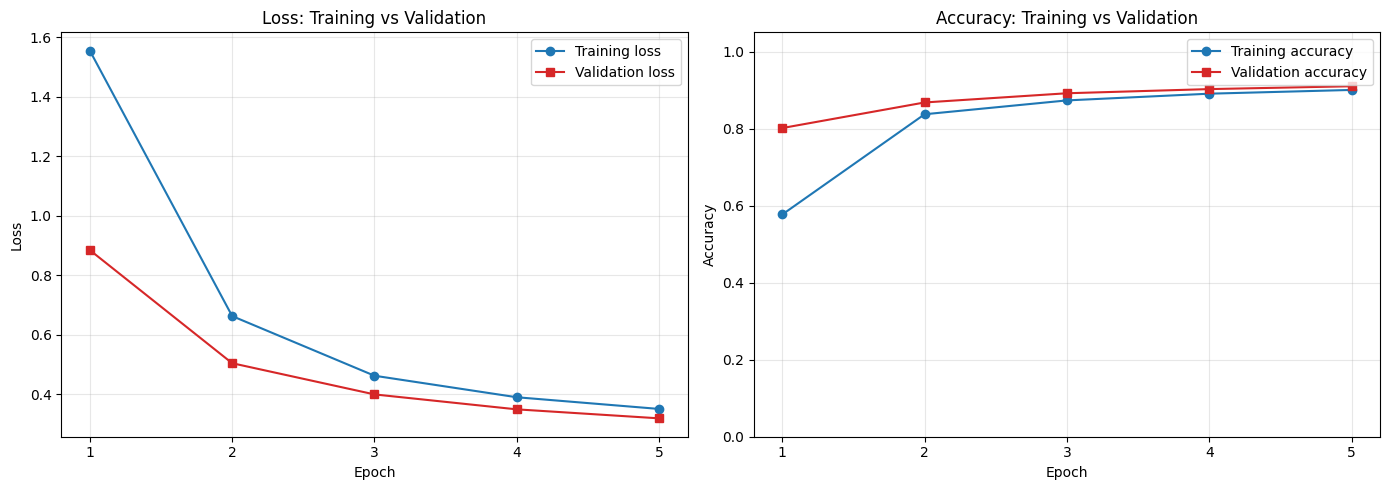

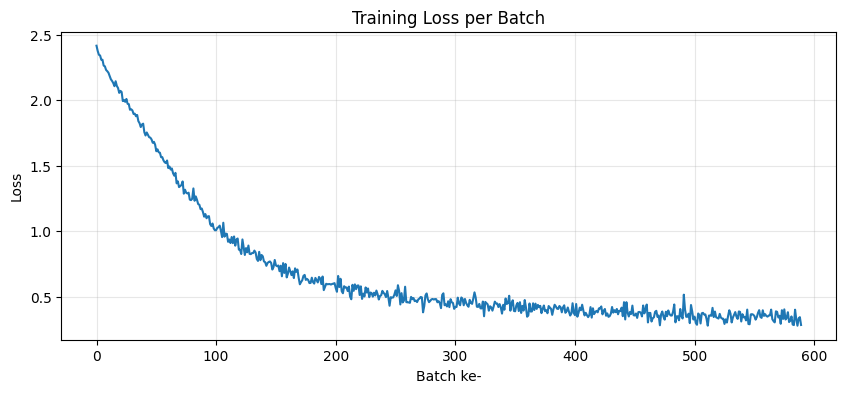

In [35]:
# Full training
params,history = train_cnn_with_history(
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=5,
    batch_size=512,
    lr=0.01
)
# Plot hasil
plot_training_history(history)
plot_batch_loss(history)